In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CSV File for Almonds

Credits to:
https://www.kaggle.com/datasets/sohaibmoradi/almond-types-classification/data

In [274]:
#Utilities
def report(dfs, names):
    
    rep = pd.DataFrame(dfs[0].dtypes, columns=['dtypes'])
    
    for i, df in enumerate(dfs):
        rep[f"{names[i]}_missing#"] = dfs[i].isna().sum()
        rep[f"{names[i]}_missing%"] = (dfs[i].isna().sum())/len(dfs[i])
        rep[f"{names[i]}_uniques"] = dfs[i].nunique().values

    return rep

# Dirty Version of the dataset

## Preprocessing Information

In [275]:
almond = pd.read_csv("Datasets/almond_dirty.csv", sep=",")
almond

,Unnamed: 0,Length (major axis),Width (minor axis),Thickness (depth),Area,Perimeter,Roundness,Solidity,Compactness,Aspect Ratio,Eccentricity,Extent,Convex hull(convex area),Type
0,0,NaN,227.940628,127.759132,22619.0,643.813269,NaN,0.973384,1.458265,NaN,NaN,0.681193,23237.5,MAMRA
1,1,NaN,234.188126,128.199509,23038.0,680.984841,NaN,0.957304,1.601844,NaN,NaN,0.656353,24065.5,MAMRA
2,2,NaN,229.418610,125.796547,22386.5,646.943212,NaN,0.967270,1.487772,NaN,NaN,0.683620,23144.0,MAMRA
3,3,NaN,232.763153,125.918808,22578.5,661.227483,NaN,0.965512,1.540979,NaN,NaN,0.685360,23385.0,MAMRA
4,4,NaN,230.150742,107.253448,19068.0,624.842706,NaN,0.951450,1.629395,NaN,NaN,0.714800,20041.0,MAMRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,2798,NaN,192.709366,122.356506,18471.5,653.345233,NaN,0.931000,1.838965,NaN,NaN,0.725739,19840.5,SANORA
2799,2799,NaN,186.254745,118.708961,17213.5,581.688379,NaN,0.952706,1.564234,NaN,NaN,0.714016,18068.0,SANORA
2800,2800,NaN,186.196182,119.147224,17510.5,608.315795,NaN,0.948821,1.681705,NaN,NaN,0.718999,18455.0,SANORA
2801,2801,NaN,188.660828,120.634438,17941.0,630.759446,NaN,0.944810,1.764701,NaN,NaN,0.738191,18989.0,SANORA


In [276]:
dfs = [almond]
names = ["almond"]
rep = report(dfs, names)
rep

,dtypes,almond_missing#,almond_missing%,almond_uniques
Unnamed: 0,int64,0,0.000000,2803
Length (major axis),float64,857,0.305744,1944
Width (minor axis),float64,942,0.336068,1859
Thickness (depth),float64,1004,0.358188,1797
Area,float64,0,0.000000,2750
Perimeter,float64,0,0.000000,2793
Roundness,float64,857,0.305744,1944
Solidity,float64,0,0.000000,2800
Compactness,float64,0,0.000000,2800
Aspect Ratio,float64,1799,0.641812,1003


In [277]:
almond.info()

<class 'pandas.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2803 non-null   int64  
 1   Length (major axis)       1946 non-null   float64
 2   Width (minor axis)        1861 non-null   float64
 3   Thickness (depth)         1799 non-null   float64
 4   Area                      2803 non-null   float64
 5   Perimeter                 2803 non-null   float64
 6   Roundness                 1946 non-null   float64
 7   Solidity                  2803 non-null   float64
 8   Compactness               2803 non-null   float64
 9   Aspect Ratio              1004 non-null   float64
 10  Eccentricity              1004 non-null   float64
 11  Extent                    2803 non-null   float64
 12  Convex hull(convex area)  2803 non-null   float64
 13  Type                      2803 non-null   str    
dtypes: float64(12), int

In [278]:
almond.describe()

,Unnamed: 0,Length (major axis),Width (minor axis),Thickness (depth),Area,Perimeter,Roundness,Solidity,Compactness,Aspect Ratio,Eccentricity,Extent,Convex hull(convex area)
count,2803.000000,1946.000000,1861.000000,1799.000000,2803.000000,2803.000000,1946.000000,2803.000000,2803.000000,1004.000000,1004.000000,2803.000000,2803.000000
mean,1401.000000,290.609274,171.025915,109.705378,26511.117374,743.863770,0.470466,0.955828,1.825233,1.753216,0.813114,0.724587,27696.218159
std,809.300727,62.719433,29.916529,18.940597,13782.561344,230.632076,0.118673,0.039596,0.794058,0.206616,0.041312,0.047474,14237.347610
min,0.000000,151.335266,88.050529,59.494278,6037.000000,311.563489,0.173748,0.718772,1.164469,1.400082,0.699897,0.454538,6355.000000
25%,700.500000,245.966293,149.453659,97.091682,16211.500000,571.730009,0.384810,0.944579,1.357398,1.612490,0.784476,0.701673,17088.500000
50%,1401.000000,279.879883,170.168365,110.280136,23440.500000,707.487369,0.472718,0.970422,1.576412,1.705716,0.810120,0.733720,24589.000000
75%,2101.500000,330.508575,190.640427,121.392773,33451.000000,878.896530,0.577553,0.981484,1.965953,1.833339,0.838141,0.757551,34863.250000
max,2802.000000,515.352478,258.569794,181.845200,89282.000000,1864.947387,0.697293,0.992889,9.660057,2.731251,0.930563,0.845813,90642.500000


## Renaming Columns

In [279]:
#Proper column naming
almond.columns = almond.columns.str.strip().str.lower().str.replace(" ", "_")
almond.drop(columns=["unnamed:_0"], inplace=True)
almond.rename(columns={"length_(major_axis)":"length", "width_(minor_axis)":"width", "thickness_(depth)":"thickness", "convex_hull(convex_area)":"convex_hull"}, inplace=True)
almond_dirty = almond.copy() #Keep a copy of the original dataset for reference
almond


,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,NaN,227.940628,127.759132,22619.0,643.813269,NaN,0.973384,1.458265,NaN,NaN,0.681193,23237.5,MAMRA
1,NaN,234.188126,128.199509,23038.0,680.984841,NaN,0.957304,1.601844,NaN,NaN,0.656353,24065.5,MAMRA
2,NaN,229.418610,125.796547,22386.5,646.943212,NaN,0.967270,1.487772,NaN,NaN,0.683620,23144.0,MAMRA
3,NaN,232.763153,125.918808,22578.5,661.227483,NaN,0.965512,1.540979,NaN,NaN,0.685360,23385.0,MAMRA
4,NaN,230.150742,107.253448,19068.0,624.842706,NaN,0.951450,1.629395,NaN,NaN,0.714800,20041.0,MAMRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,NaN,192.709366,122.356506,18471.5,653.345233,NaN,0.931000,1.838965,NaN,NaN,0.725739,19840.5,SANORA
2799,NaN,186.254745,118.708961,17213.5,581.688379,NaN,0.952706,1.564234,NaN,NaN,0.714016,18068.0,SANORA
2800,NaN,186.196182,119.147224,17510.5,608.315795,NaN,0.948821,1.681705,NaN,NaN,0.718999,18455.0,SANORA
2801,NaN,188.660828,120.634438,17941.0,630.759446,NaN,0.944810,1.764701,NaN,NaN,0.738191,18989.0,SANORA


## Cleaning the Dataset

### Null Values

In [280]:
almond.isnull().sum()

length           857
width            942
thickness       1004
area               0
perimeter          0
roundness        857
solidity           0
compactness        0
aspect_ratio    1799
eccentricity    1799
extent             0
convex_hull        0
type               0
dtype: int64

### Length Cleaning

In [281]:
#Current Length
print("Null Values in length:", almond["length"].isnull().sum())

#Calculate the mean per almond type
sanora_length = almond[almond["type"] == "SANORA"]["length"].mean()
mamra_length = almond[almond["type"] == "MAMRA"]["length"].mean()
regular_length = almond[almond["type"] == "REGULAR"]["length"].mean()
print(f"Mean Length for SANORA: {sanora_length}")
print(f"Mean Length for MAMRA: {mamra_length}")
print(f"Mean Length for REGULAR: {regular_length}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["length"].isnull()), "length"] = sanora_length
almond.loc[(almond["type"] == "MAMRA") & (almond["length"].isnull()), "length"] = mamra_length
almond.loc[(almond["type"] == "REGULAR") & (almond["length"].isnull()), "length"] = regular_length

#Check results
print("="*100)
print("Null Values in length:", almond["length"].isnull().sum())

Null Values in length: 857
Mean Length for SANORA: 283.2453471183777
Mean Length for MAMRA: 321.8072439781705
Mean Length for REGULAR: 265.5956452796686
Null Values in length: 0


### Width Cleaning

In [282]:
#Current Width
print("Null Values in width:", almond["width"].isnull().sum())

#Calculate the mean per almond type
sanora_width = almond[almond["type"] == "SANORA"]["width"].mean()
mamra_width = almond[almond["type"] == "MAMRA"]["width"].mean()
regular_width = almond[almond["type"] == "REGULAR"]["width"].mean()
print(f"Mean Width for SANORA: {sanora_width}")
print(f"Mean Width for MAMRA: {mamra_width}")
print(f"Mean Width for REGULAR: {regular_width}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["width"].isnull()), "width"] = sanora_width
almond.loc[(almond["type"] == "MAMRA") & (almond["width"].isnull()), "width"] = mamra_width
almond.loc[(almond["type"] == "REGULAR") & (almond["width"].isnull()), "width"] = regular_width

#Check results
print("="*100)
print("Null Values in width:", almond["width"].isnull().sum())

Null Values in width: 942
Mean Width for SANORA: 180.12266856479798
Mean Width for MAMRA: 171.5635312945839
Mean Width for REGULAR: 161.1988074619524
Null Values in width: 0


### Thickness Cleaning

In [283]:
#Current Thickness
print("Null Values in thickness:", almond["thickness"].isnull().sum())

#Calculate the mean per almond type
sanora_thickness = almond[almond["type"] == "SANORA"]["thickness"].mean()
mamra_thickness = almond[almond["type"] == "MAMRA"]["thickness"].mean()
regular_thickness = almond[almond["type"] == "REGULAR"]["thickness"].mean()
print(f"Mean Thickness for SANORA: {sanora_thickness}")
print(f"Mean Thickness for MAMRA: {mamra_thickness}")
print(f"Mean Thickness for REGULAR: {regular_thickness}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["thickness"].isnull()), "thickness"] = sanora_thickness
almond.loc[(almond["type"] == "MAMRA") & (almond["thickness"].isnull()), "thickness"] = mamra_thickness
almond.loc[(almond["type"] == "REGULAR") & (almond["thickness"].isnull()), "thickness"] = regular_thickness

#Check results
print("="*100)
print("Null Values in thickness:", almond["thickness"].isnull().sum())

Null Values in thickness: 1004
Mean Thickness for SANORA: 115.3717401666779
Mean Thickness for MAMRA: 100.80497747680451
Mean Thickness for REGULAR: 112.3277803085175
Null Values in thickness: 0


### Roundness Cleaning

In [284]:
#Current Roundness
print("Null Values in roundness:", almond["roundness"].isnull().sum())

#Calculate the mean per almond type
sanora_roundness = almond[almond["type"] == "SANORA"]["roundness"].mean()
mamra_roundness = almond[almond["type"] == "MAMRA"]["roundness"].mean()
regular_roundness = almond[almond["type"] == "REGULAR"]["roundness"].mean()
print(f"Mean Roundness for SANORA: {sanora_roundness}")
print(f"Mean Roundness for MAMRA: {mamra_roundness}")
print(f"Mean Roundness for REGULAR: {regular_roundness}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["roundness"].isnull()), "roundness"] = sanora_roundness
almond.loc[(almond["type"] == "MAMRA") & (almond["roundness"].isnull()), "roundness"] = mamra_roundness
almond.loc[(almond["type"] == "REGULAR") & (almond["roundness"].isnull()), "roundness"] = regular_roundness

#Check results
print("="*100)
print("Null Values in roundness:", almond["roundness"].isnull().sum())

Null Values in roundness: 857
Mean Roundness for SANORA: 0.5000446964470665
Mean Roundness for MAMRA: 0.40384917807670795
Mean Roundness for REGULAR: 0.5100437334904849
Null Values in roundness: 0


### Aspect Ratio Cleaning

In [285]:
#Current Thickness
print("Null Values in aspect_ratio:", almond["aspect_ratio"].isnull().sum())

#Calculate the mean per almond type
sanora_aspect_ratio = almond[almond["type"] == "SANORA"]["aspect_ratio"].mean()
mamra_aspect_ratio = almond[almond["type"] == "MAMRA"]["aspect_ratio"].mean()
regular_aspect_ratio = almond[almond["type"] == "REGULAR"]["aspect_ratio"].mean()
print(f"Mean Aspect Ratio for SANORA: {sanora_aspect_ratio}")
print(f"Mean Aspect Ratio for MAMRA: {mamra_aspect_ratio}")
print(f"Mean Aspect Ratio for REGULAR: {regular_aspect_ratio}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["aspect_ratio"].isnull()), "aspect_ratio"] = sanora_aspect_ratio
almond.loc[(almond["type"] == "MAMRA") & (almond["aspect_ratio"].isnull()), "aspect_ratio"] = mamra_aspect_ratio
almond.loc[(almond["type"] == "REGULAR") & (almond["aspect_ratio"].isnull()), "aspect_ratio"] = regular_aspect_ratio

#Check results
print("="*100)
print("Null Values in aspect_ratio:", almond["aspect_ratio"].isnull().sum())

Null Values in aspect_ratio: 1799
Mean Aspect Ratio for SANORA: 1.634304535099497
Mean Aspect Ratio for MAMRA: 1.9230846417924636
Mean Aspect Ratio for REGULAR: 1.6826570319876815
Null Values in aspect_ratio: 0


### Eccentricity Cleanig

In [286]:
#Current Thickness
print("Null Values in eccentricity:", almond["eccentricity"].isnull().sum())

#Calculate the mean per almond type
sanora_eccentricity = almond[almond["type"] == "SANORA"]["eccentricity"].mean()
mamra_eccentricity = almond[almond["type"] == "MAMRA"]["eccentricity"].mean()
regular_eccentricity = almond[almond["type"] == "REGULAR"]["eccentricity"].mean()
print(f"Mean Eccentricity for SANORA: {sanora_eccentricity}")
print(f"Mean Eccentricity for MAMRA: {mamra_eccentricity}")
print(f"Mean Eccentricity for REGULAR: {regular_eccentricity}")

#Assign new values
almond.loc[(almond["type"] == "SANORA") & (almond["eccentricity"].isnull()), "eccentricity"] = sanora_eccentricity
almond.loc[(almond["type"] == "MAMRA") & (almond["eccentricity"].isnull()), "eccentricity"] = mamra_eccentricity
almond.loc[(almond["type"] == "REGULAR") & (almond["eccentricity"].isnull()), "eccentricity"] = regular_eccentricity

#Check results
print("="*100)
print("Null Values in eccentricity:", almond["eccentricity"].isnull().sum())

Null Values in eccentricity: 1799
Mean Eccentricity for SANORA: 0.7890775098134641
Mean Eccentricity for MAMRA: 0.8463276806400367
Mean Eccentricity for REGULAR: 0.8000936025732689
Null Values in eccentricity: 0


# Cleaned Version of the Dataset

## New dataset information

In [287]:
almond

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,321.807244,227.940628,127.759132,22619.0,643.813269,0.403849,0.973384,1.458265,1.923085,0.846328,0.681193,23237.5,MAMRA
1,321.807244,234.188126,128.199509,23038.0,680.984841,0.403849,0.957304,1.601844,1.923085,0.846328,0.656353,24065.5,MAMRA
2,321.807244,229.418610,125.796547,22386.5,646.943212,0.403849,0.967270,1.487772,1.923085,0.846328,0.683620,23144.0,MAMRA
3,321.807244,232.763153,125.918808,22578.5,661.227483,0.403849,0.965512,1.540979,1.923085,0.846328,0.685360,23385.0,MAMRA
4,321.807244,230.150742,107.253448,19068.0,624.842706,0.403849,0.951450,1.629395,1.923085,0.846328,0.714800,20041.0,MAMRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,283.245347,192.709366,122.356506,18471.5,653.345233,0.500045,0.931000,1.838965,1.634305,0.789078,0.725739,19840.5,SANORA
2799,283.245347,186.254745,118.708961,17213.5,581.688379,0.500045,0.952706,1.564234,1.634305,0.789078,0.714016,18068.0,SANORA
2800,283.245347,186.196182,119.147224,17510.5,608.315795,0.500045,0.948821,1.681705,1.634305,0.789078,0.718999,18455.0,SANORA
2801,283.245347,188.660828,120.634438,17941.0,630.759446,0.500045,0.944810,1.764701,1.634305,0.789078,0.738191,18989.0,SANORA


In [288]:
dfs = [almond]
names = ["almond"]
rep = report(dfs, names)
rep

,dtypes,almond_missing#,almond_missing%,almond_uniques
length,float64,0,0.0,1947
width,float64,0,0.0,1862
thickness,float64,0,0.0,1800
area,float64,0,0.0,2750
perimeter,float64,0,0.0,2793
roundness,float64,0,0.0,1947
solidity,float64,0,0.0,2800
compactness,float64,0,0.0,2800
aspect_ratio,float64,0,0.0,1006
eccentricity,float64,0,0.0,1006


In [289]:
almond.info()

<class 'pandas.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   length        2803 non-null   float64
 1   width         2803 non-null   float64
 2   thickness     2803 non-null   float64
 3   area          2803 non-null   float64
 4   perimeter     2803 non-null   float64
 5   roundness     2803 non-null   float64
 6   solidity      2803 non-null   float64
 7   compactness   2803 non-null   float64
 8   aspect_ratio  2803 non-null   float64
 9   eccentricity  2803 non-null   float64
 10  extent        2803 non-null   float64
 11  convex_hull   2803 non-null   float64
 12  type          2803 non-null   str    
dtypes: float64(12), str(1)
memory usage: 284.8 KB


In [290]:
almond.describe()

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull
count,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000,2803.000000
mean,290.243912,171.015250,109.516392,26511.117374,743.863770,0.471332,0.955828,1.825233,1.746418,0.811777,0.724587,27696.218159
std,53.789147,24.788778,15.645452,13782.561344,230.632076,0.102245,0.039596,0.794058,0.159248,0.031623,0.047474,14237.347610
min,151.335266,88.050529,59.494278,6037.000000,311.563489,0.173748,0.718772,1.164469,1.400082,0.699897,0.454538,6355.000000
25%,264.115860,160.297798,100.804977,16211.500000,571.730009,0.403849,0.944579,1.357398,1.634305,0.789078,0.701673,17088.500000
50%,283.245347,171.563531,112.327780,23440.500000,707.487369,0.500045,0.970422,1.576412,1.682657,0.800094,0.733720,24589.000000
75%,321.807244,180.152008,115.371740,33451.000000,878.896530,0.538321,0.981484,1.965953,1.923085,0.846328,0.757551,34863.250000
max,515.352478,258.569794,181.845200,89282.000000,1864.947387,0.697293,0.992889,9.660057,2.731251,0.930563,0.845813,90642.500000


In [291]:
almond.isnull().sum()

length          0
width           0
thickness       0
area            0
perimeter       0
roundness       0
solidity        0
compactness     0
aspect_ratio    0
eccentricity    0
extent          0
convex_hull     0
type            0
dtype: int64

## Export the new data

In [292]:
almond.to_csv("Datasets/almond_clean.csv", index=False)
print("Cleaned dataset saved as almond_clean.csv")

Cleaned dataset saved as almond_clean.csv


# Exploratory Data Analysis

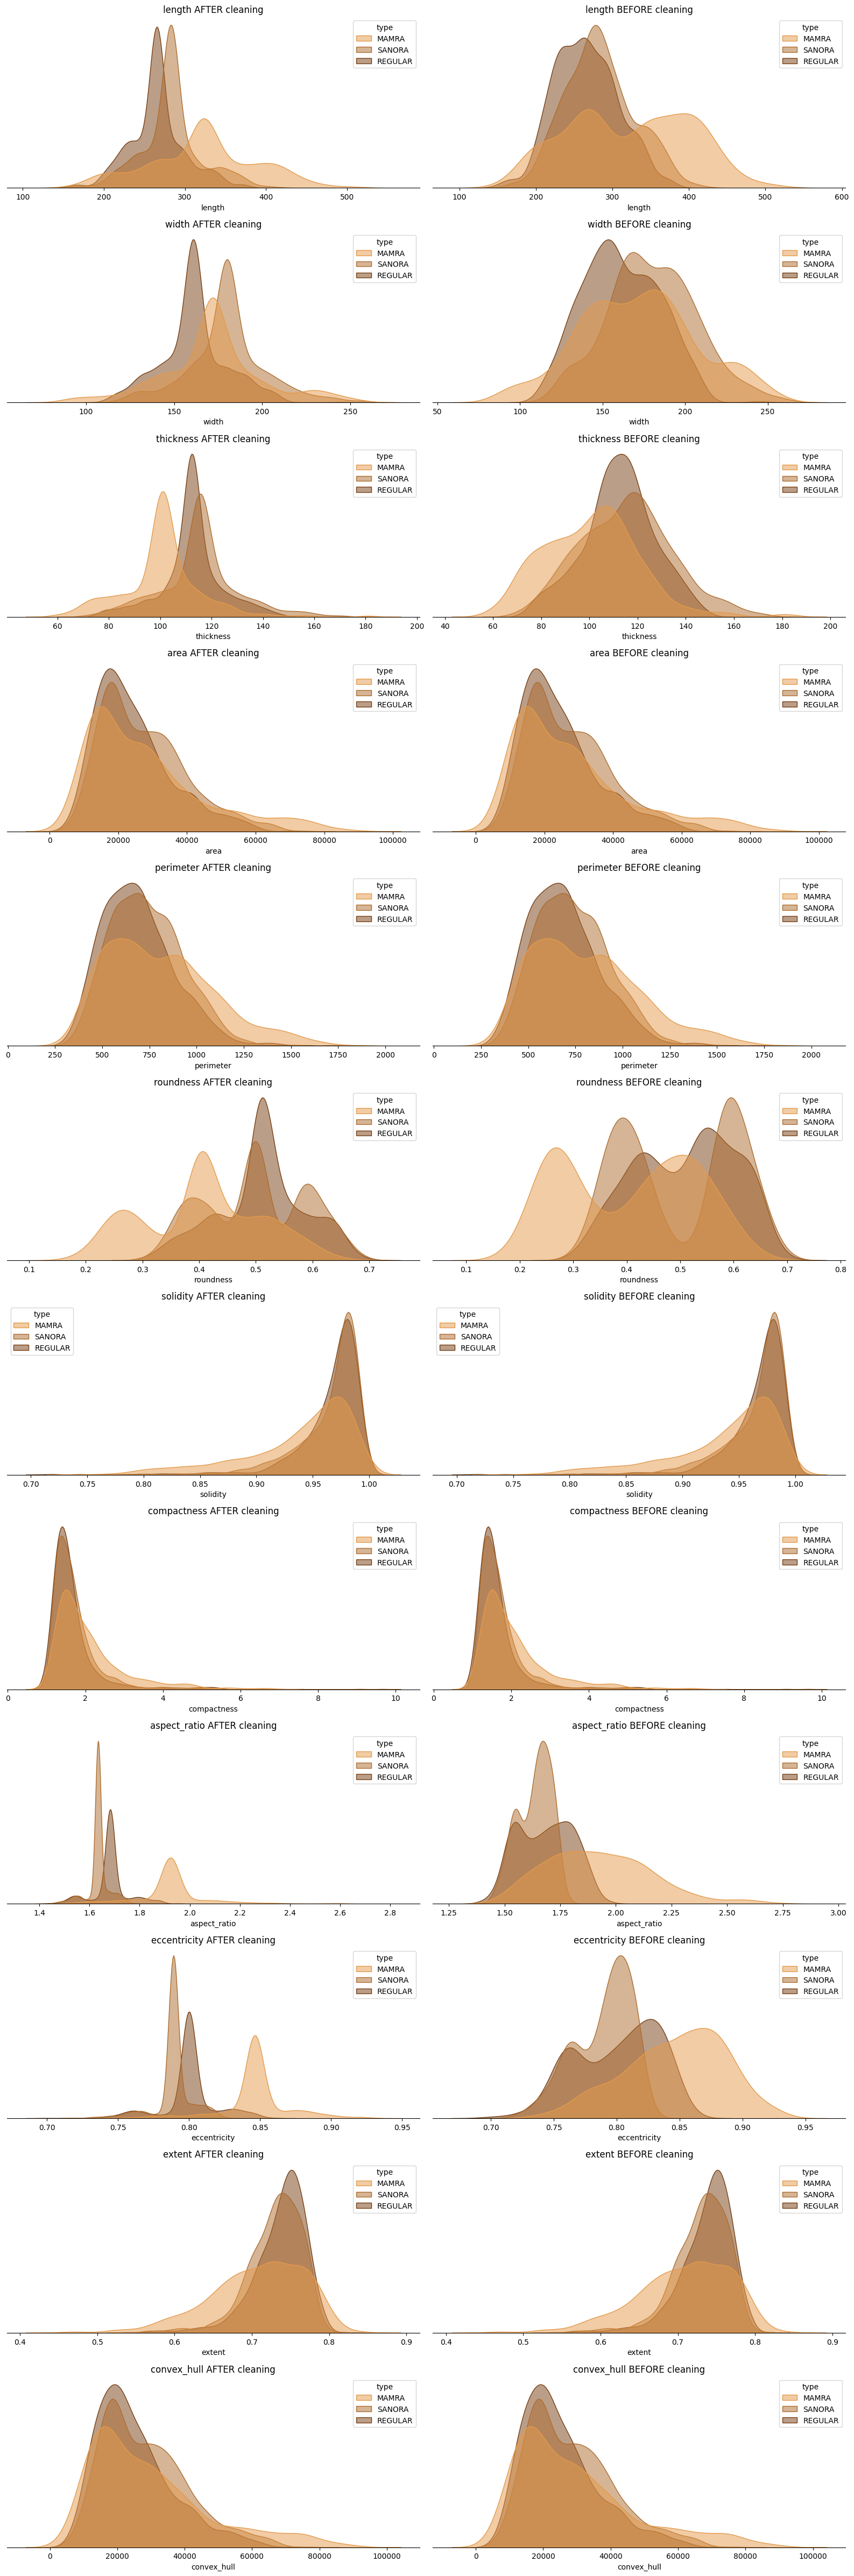

In [ ]:
almond_clean = almond.copy()
target_col = "type"

columns = almond_clean.drop([target_col], axis=1).columns

fig, axes = plt.subplots(len(columns), 2, figsize=(16, len(columns) * 4))

for i, col in enumerate(columns):
    
    # Left Column: CLEAN data
    sns.kdeplot(data=almond_clean, x=col, hue=target_col,
                ax=axes[i, 0], fill=True,
                palette="blend:#e49a4c,#773e13", alpha=.5)
    axes[i, 0].set_title(f"{col} AFTER cleaning")
    
    # Right Column: DIRTY data
    sns.kdeplot(data=almond_dirty, x=col, hue=target_col,
                ax=axes[i, 1], fill=True,
                palette="blend:#e49a4c,#773e13", alpha=.5)
    axes[i, 1].set_title(f"{col} BEFORE cleaning")
    
    for j in [0, 1]:
        axes[i, j].set_yticklabels([])
        axes[i, j].set_ylabel("")
        axes[i, j].tick_params(axis="y", length=0)
        for direction in ["top", "right", "left"]:
            axes[i, j].spines[direction].set_visible(False)

plt.tight_layout()
plt.show()